# Accessing the Digital Earth Normalised Radar Backscatter Product for Sentinel-1 (Collection 1) Using the Digital Earth Australia Sandbox

This notebook shows a number of additional features that can be taken advantage of when loading through the Digital Earth Australia Sandbox, which is directly connected to Digital Earth Australia's Open Data Cube.

## Important Datacube terminology
Data stored in an Open Data Cube has three important components:

* **Product**: A structure for organising all datasets in a single group.
* **Dataset**: A single spatio-temporal dataset, which would contain multiple measurements.
* **Measurement**: A single data measurement associated with a dataset, such as a single band.

For the Normalised Radar Backscatter data, it is important to note that a single *dataset* corresponds to a single *burst* from a larger acquisition.

## Set-up

Note that to use this notebook, you must be in the Digital Earth Australia production Sandbox, and you must have completed the [required steps](https://docs.dev.dea.ga.gov.au/services/dea-sandbox/dev_database_from_prod_jupyterhub/) to connect to the dev Datacube database.

Instructions are only available to Geoscience Australia employees.

### Import required libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from odc.geo import BoundingBox
import odc.geo.xr
import pathlib
import xarray as xr
import datacube

### Environment set up

In [2]:
dc = datacube.Datacube(env="dev", app="S1_Backscatter_Demo")

## Interrogating products and datasets

### View available products

In [3]:
dc_products = dc.list_products()
dc_products.loc[dc_products["name"].str.contains("ga_s1_nrb_iw")]

,name,description,license,default_crs,default_resolution
name,,,,,
ga_s1_nrb_iw_hh_0,ga_s1_nrb_iw_hh_0,Geoscience Australia Sentinel-1 Interferometri...,CC-BY-4.0,None,None
ga_s1_nrb_iw_hh_1,ga_s1_nrb_iw_hh_1,Geoscience Australia Sentinel-1 Interferometri...,CC-BY-4.0,None,None
ga_s1_nrb_iw_hh_hv_0,ga_s1_nrb_iw_hh_hv_0,Geoscience Australia Sentinel-1 Interferometri...,CC-BY-4.0,None,None
ga_s1_nrb_iw_hh_hv_1,ga_s1_nrb_iw_hh_hv_1,Geoscience Australia Sentinel-1 Interferometri...,CC-BY-4.0,None,None
ga_s1_nrb_iw_vv_0,ga_s1_nrb_iw_vv_0,Geoscience Australia Sentinel-1 Interferometri...,CC-BY-4.0,None,None
ga_s1_nrb_iw_vv_1,ga_s1_nrb_iw_vv_1,Geoscience Australia Sentinel-1 Interferometri...,CC-BY-4.0,None,None
ga_s1_nrb_iw_vv_vh_0,ga_s1_nrb_iw_vv_vh_0,Geoscience Australia Sentinel-1 Interferometri...,CC-BY-4.0,None,None
ga_s1_nrb_iw_vv_vh_1,ga_s1_nrb_iw_vv_vh_1,Geoscience Australia Sentinel-1 Interferometri...,CC-BY-4.0,None,None


### View product measurements

In [6]:
dc_measurements = dc.list_measurements()
dc_measurements.loc['ga_s1_nrb_iw_hh_1']

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
hh_gamma0,hh_gamma0,float32,linear power,NaN,[hh],NaN
oa_layover_shadow_mask,oa_layover_shadow_mask,uint8,classification,255,[mask],"{'oa_layover_shadow_mask': {'bits': [0, 1, 2, ..."
oa_number_of_looks,oa_number_of_looks,float32,count,NaN,"[n_looks, nlooks, number_of_looks]",NaN
oa_gamma0_to_beta0_ratio,oa_gamma0_to_beta0_ratio,float32,ratio,NaN,"[gamma0_to_beta0_ratio, gamma0_to_beta0]",NaN
oa_gamma0_to_sigma0_ratio,oa_gamma0_to_sigma0_ratio,float32,ratio,NaN,"[gamma0_to_sigma0_ratio, gamma0_to_sigma0]",NaN
oa_local_incidence_angle,oa_local_incidence_angle,float32,degrees,NaN,"[lia, LIA, local_incidence_angle]",NaN
oa_incidence_angle,oa_incidence_angle,float32,degrees,NaN,"[ia, IA, incidence_angle]",NaN


### View product metadata

Products contain many additional metadata fields that can be valuable for filtering.

In [7]:
dc.index.products.get_by_name("ga_s1_nrb_iw_hh_1").fields

{'creation_time': None,
 'format': None,
 'label': None,
 'lat': None,
 'lon': None,
 'time': None,
 'beam_id': None,
 'crs_raw': None,
 'burst_id': None,
 'platform': None,
 'scene_id': None,
 'source_id': None,
 'instrument': None,
 'orbit_file': None,
 'orbit_cycle': None,
 'orbit_state': None,
 'region_code': None,
 'orbit_source': None,
 'conversion_eq': None,
 'absolute_orbit': None,
 'product_family': 'sar_ard',
 'relative_orbit': None,
 'dataset_version': None,
 'instrument_mode': None,
 'measurement_type': None,
 'noise_removal_applied': None,
 'observation_direction': None,
 'measurement_convention': None,
 'speckle_filter_applied': None,
 'far_range_incidence_angle': None,
 'near_range_incidence_angle': None,
 'bistatic_correction_applied': None,
 'ionospheric_correction_applied': None,
 'wet_tropospheric_correction_applied': None,
 'static_tropospheric_correction_applied': None}

### View dataset metadata

The actual metadata values are available on a dataset level. For this example, we show the metadata associated with a specific item, [ga_s1b_nrb_1-0-0_T003-005802-IW2_20200113T222629Z](https://explorer.dev.dea.ga.gov.au/products/ga_s1_nrb_iw_hh_1/datasets/692f0428-5cb7-5ee1-84df-73099e99027b), which has a dataset id of `692f0428-5cb7-5ee1-84df-73099e99027b`

In [8]:
single_dataset = dc.index.datasets.get("692f0428-5cb7-5ee1-84df-73099e99027b")

single_dataset.metadata.search_fields

{'creation_time': datetime.datetime(2026, 4, 15, 4, 19, 22, 684780, tzinfo=datetime.timezone.utc),
 'format': 'GeoTIFF',
 'label': None,
 'lat': Range(begin=-68.98536970834435, end=-68.3597900936621),
 'lon': Range(begin=77.12722874709115, end=79.1738568408492),
 'time': Range(begin=datetime.datetime(2020, 1, 13, 22, 26, 29, 841903, tzinfo=datetime.timezone.utc), end=datetime.datetime(2020, 1, 13, 22, 26, 31, 903903, tzinfo=datetime.timezone.utc)),
 'beam_id': 'IW2',
 'crs_raw': 'EPSG:3031',
 'burst_id': 't003_005802_iw2',
 'platform': 'Sentinel-1B',
 'scene_id': 'S1B_IW_SLC__1SSH_20200113T222621_20200113T222648_019804_025722_4B48',
 'source_id': 'S1B_IW_SLC__1SSH_20200113T222621_20200113T222648_019804_025722_4B48.SAFE',
 'instrument': 'SENTINEL-1B CSAR',
 'orbit_file': 'S1B_OPER_AUX_POEORB_OPOD_20210316T220417_V20200112T225942_20200114T005942.EOF',
 'orbit_cycle': 12,
 'orbit_state': 'descending',
 'region_code': 't003_005802_iw2',
 'orbit_source': 'POE precise orbit',
 'conversion_eq

## Basic search and load

When working with the Open Data Cube datacube API, it is possible to do searching and loading with a single call of the `dc.load()` function.

### Set search and load parameters

In [12]:
# Products to query
product_to_load = "ga_s1_nrb_iw_hh_1"

# Area of interest
aoi_bbox = BoundingBox(
    left=73.5,
    bottom=-69.1,
    right=74.0,
    top=-68.8,
    crs="EPSG:4326"
)

# Date range of interest
start_date = "2021-01-01"
end_date = "2021-03-01"

# Measurements to load
measurements_to_load = ["hh_gamma0", "oa_layover_shadow_mask"]

# CRS and resolution
output_crs = "EPSG:3031"
output_res = 200 # When loading a larger area, you can save time and memory by increasing the pixel size (lower resolution)

# Property or function to group by. "solar_day" is already built into odc-stac
groupy_by_operation = "solar_day"

aoi_bbox.explore()

### Run load

Note that the load function takes:

* `product`: the product, or list of products to load from.
* `measurements`: the measurements to load from the data (e.g. VV). If not specified, all measurements will be loaded.
* `lat`: a tuple of latitude values (bottom, top)
* `lon`: a tuple of longitude values (left, right)
* `output_crs`: the coordinate reference system (CRS) to project loaded data to. If not specified, the data's native CRS will be used.
* `resolution`: the resolution to load the data at, in the same units as the chosen CRS. If not specified, the data's native resolution will be used.
* `time`: a tuple of (start, end) indicating the date range.
* `group_by`: how to group loaded data. Solar day is a sensible default.

See the [API](https://opendatacube.readthedocs.io/en/latest/api/core-classes/datacube.html#datacube.Datacube.load) for more information

In [13]:
ds = dc.load(
    product=product_to_load,
    measurements=measurements_to_load,
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=(start_date, end_date),
    group_by=groupy_by_operation,
    dask_chunks={}
)

### View the lazy-loaded xarray

In [14]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:                 (time: 15, y: 145, x: 190)
Coordinates:
  * time                    (time) datetime64[ns] 120B 2021-01-01T22:27:36.88...
  * y                       (y) float64 1kB 6.327e+05 6.329e+05 ... 6.615e+05
  * x                       (x) float64 2kB 2.239e+06 2.238e+06 ... 2.201e+06
    spatial_ref             int32 4B 3031
Data variables:
    hh_gamma0               (time, y, x) float32 2MB dask.array<chunksize=(1, 145, 190), meta=np.ndarray>
    oa_layover_shadow_mask  (time, y, x) uint8 413kB dask.array<chunksize=(1, 145, 190), meta=np.ndarray>
Attributes:
    crs:           EPSG:3031
    grid_mapping:  spatial_ref

### Compute the lazy loaded xarray
To save time and memory for this demonstration, we'll only compute the first three time-steps.

In [15]:
ds = ds.isel(time=range(0,3)).compute()

ds

<xarray.Dataset> Size: 416kB
Dimensions:                 (time: 3, y: 145, x: 190)
Coordinates:
  * time                    (time) datetime64[ns] 24B 2021-01-01T22:27:36.884...
  * y                       (y) float64 1kB 6.327e+05 6.329e+05 ... 6.615e+05
  * x                       (x) float64 2kB 2.239e+06 2.238e+06 ... 2.201e+06
    spatial_ref             int32 4B 3031
Data variables:
    hh_gamma0               (time, y, x) float32 331kB 0.09136 0.1909 ... nan
    oa_layover_shadow_mask  (time, y, x) uint8 83kB 0 0 0 0 ... 255 255 255 255
Attributes:
    crs:           EPSG:3031
    grid_mapping:  spatial_ref

### Visualise

This step shows how to visualise the first three time-steps from the xarray.
After grouping by solar day, you can see how the Sentinel-1 orbit tracks influence where data is and isn't captured on a given day.

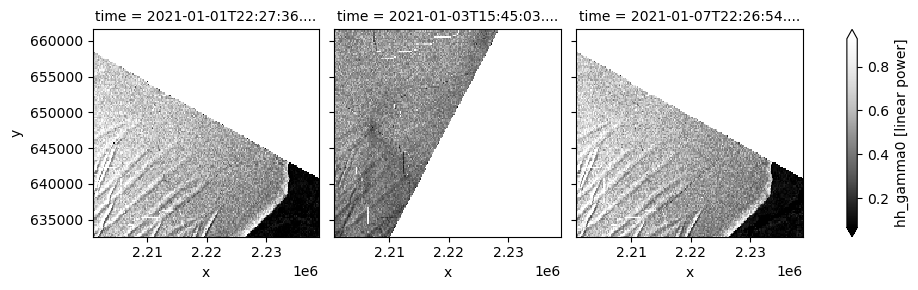

In [17]:
ds.isel(time=range(0,3))["hh_gamma0"].plot.imshow(col="time", col_wrap=3, robust=True, cmap="Greys_r")

## Advanced approaches

### Searching before loading

While `dc.load()` can combine searching and loading, the `datacube` library also has a `find_datasets()` fucntion, which returns a list of datasets that can then be loaded.
This can be helpful when wanting to filter datasets on specific metadata properties prior to loading.

See the [API](https://opendatacube.readthedocs.io/en/latest/api/core-classes/datacube.html#datacube.Datacube.find_datasets) for more information.

In [18]:
datasets = dc.find_datasets(
    product=product_to_load,
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    time=(start_date, end_date),
)

print(f"Found {len(datasets)} datasets")

Found 45 datasets


### Viewing dataset-level metadata

Before loading, it can be valuable to understand the general metadata properties of the returned datasets.
For example, are your datasets primarily captured in descending or ascending passes?

In [19]:
ascending_datasets = [dataset for dataset in datasets if dataset.metadata.orbit_state=="ascending"]
print(f"Number of datasets with ascending orbit state: {len(ascending_datasets)}")

descending_datasets = [dataset for dataset in datasets if dataset.metadata.orbit_state=="descending"]
print(f"Number of datasets with descending orbit state: {len(descending_datasets)}")

Number of datasets with ascending orbit state: 15
Number of datasets with descending orbit state: 30


Alternatively, you could look at the number of unique absolute orbits (tracks) or scenes across your items.

In [20]:
unique_relative_orbits = set([dataset.metadata.relative_orbit for dataset in datasets])
print(f"The identified items come from {len(unique_relative_orbits)} unique relative orbits")
print(f"The unique relative orbit values are: {unique_relative_orbits}\n")

unique_absolute_orbits = set([dataset.metadata.absolute_orbit for dataset in datasets])
print(f"The identified items come from {len(unique_absolute_orbits)} unique absolute orbits")
print(f"The first 20 unique absolute orbit values are: {list(unique_absolute_orbits)[0:20]}\n")

unique_scene_ids = set([dataset.metadata.scene_id for dataset in datasets])
print(f"The identified items come from {len(unique_scene_ids)} unique scenes")
print(f"The first 20 unique scene ids are: {list(unique_scene_ids)[0:20]}")

The identified items come from 2 unique relative orbits
The unique relative orbit values are: {3, 28}

The identified items come from 15 unique absolute orbits
The first 20 unique absolute orbit values are: [36675, 36325, 35975, 36650, 25579, 36300, 25229, 35950, 36500, 36150, 25754, 36475, 25404, 36125, 25054]

The identified items come from 15 unique scenes
The first 20 unique scene ids are: ['S1A_IW_SLC__1SSH_20210113T222734_20210113T222801_036125_043C3C_8C68', 'S1B_IW_SLC__1SSH_20210107T222652_20210107T222719_025054_02FB76_B297', 'S1A_IW_SLC__1SSH_20210218T222733_20210218T222800_036650_044E70_1B18', 'S1B_IW_SLC__1SSH_20210212T222651_20210212T222718_025579_030C5C_72AE', 'S1B_IW_SLC__1SSH_20210224T222651_20210224T222718_025754_031212_33EE', 'S1A_IW_SLC__1SSH_20210101T222734_20210101T222801_035950_043608_4625', 'S1A_IW_SLC__1SSH_20210115T154451_20210115T154521_036150_043D18_CD50', 'S1A_IW_SLC__1SSH_20210208T154450_20210208T154520_036500_04493D_773C', 'S1A_IW_SLC__1SSH_20210103T154451_

### Loading found datasets

Having run the `dc.find_datasets()` function, it is possible to simplify the `dc.load()` function by supplying the list of datasets to load, as the product and time-range are no longer required.

In [21]:
ds_from_find = dc.load(
    datasets=datasets,
    measurements=measurements_to_load,
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    group_by=groupy_by_operation,
    dask_chunks={}
)

ds_from_find

<xarray.Dataset> Size: 2MB
Dimensions:                 (time: 15, y: 145, x: 190)
Coordinates:
  * time                    (time) datetime64[ns] 120B 2021-01-01T22:27:36.88...
  * y                       (y) float64 1kB 6.327e+05 6.329e+05 ... 6.615e+05
  * x                       (x) float64 2kB 2.239e+06 2.238e+06 ... 2.201e+06
    spatial_ref             int32 4B 3031
Data variables:
    hh_gamma0               (time, y, x) float32 2MB dask.array<chunksize=(1, 145, 190), meta=np.ndarray>
    oa_layover_shadow_mask  (time, y, x) uint8 413kB dask.array<chunksize=(1, 145, 190), meta=np.ndarray>
Attributes:
    crs:           EPSG:3031
    grid_mapping:  spatial_ref

### Loading datasets for known metadata values

If you already know the value of the metadata you wish to load on, it is possible to provide this to `dc.load()` directly by specifying the metadata name as a key-word argument.
See the [01_product_info](01_product_info.ipynb) notebook for a table containing key metadata that can be used when searching and loading.

Below, we show how to filter items for a single known `scene_id`:

In [22]:
ds_scene = dc.load(
    product=product_to_load,
    measurements=measurements_to_load,
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=(start_date, end_date),
    group_by=groupy_by_operation,
    scene_id="S1A_IW_SLC__1SSH_20210208T154450_20210208T154520_036500_04493D_773C",
    dask_chunks={}
)

ds_scene

<xarray.Dataset> Size: 140kB
Dimensions:                 (time: 1, y: 145, x: 190)
Coordinates:
  * time                    (time) datetime64[ns] 8B 2021-02-08T15:45:01.796958
  * y                       (y) float64 1kB 6.327e+05 6.329e+05 ... 6.615e+05
  * x                       (x) float64 2kB 2.239e+06 2.238e+06 ... 2.201e+06
    spatial_ref             int32 4B 3031
Data variables:
    hh_gamma0               (time, y, x) float32 110kB dask.array<chunksize=(1, 145, 190), meta=np.ndarray>
    oa_layover_shadow_mask  (time, y, x) uint8 28kB dask.array<chunksize=(1, 145, 190), meta=np.ndarray>
Attributes:
    crs:           EPSG:3031
    grid_mapping:  spatial_ref

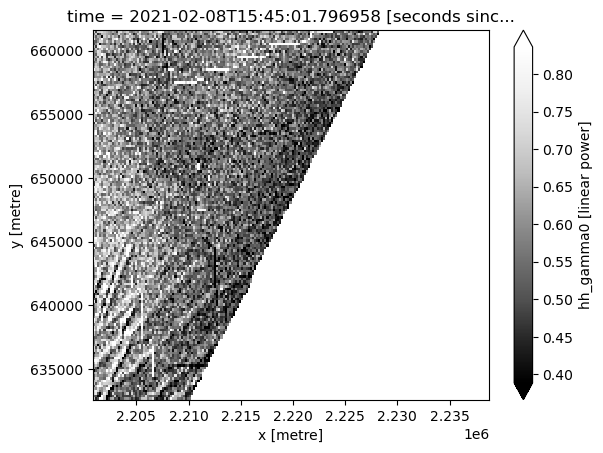

In [25]:
ds_scene.isel(time=0)["hh_gamma0"].plot.imshow(robust=True, cmap="Greys_r")

### Grouping by metadata other than solar day

It is possible to provide a custom `groupby` function which can be passed to `dc.load()`.
The below example groups items by scene, rather than by solar day.

In [26]:
from datacube.api.query import GroupBy

def group_by_scene_id():
    def by_scene_id(ds):
        return ds.metadata.scene_id

    def coord_for_group(datasets_group):
        t = min(ds.center_time for ds in datasets_group)
        return t

    return GroupBy(
        group_by_func=by_scene_id,
        dimension="time",
        units="seconds since 1970-01-01 00:00:00",
        sort_key=lambda ds: ds.center_time,
        group_key=coord_for_group,
    )

ds_by_scene = dc.load(
    product=product_to_load,
    measurements=measurements_to_load,
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=(start_date, end_date),
    group_by=group_by_scene_id(),
    dask_chunks={}
)

The effect of grouping by scene is that there are a different number of time-steps, one per scene.

In [27]:
ds_by_scene

<xarray.Dataset> Size: 2MB
Dimensions:                 (time: 15, y: 145, x: 190)
Coordinates:
  * time                    (time) datetime64[ns] 120B 2021-01-01T22:27:36.88...
  * y                       (y) float64 1kB 6.327e+05 6.329e+05 ... 6.615e+05
  * x                       (x) float64 2kB 2.239e+06 2.238e+06 ... 2.201e+06
    spatial_ref             int32 4B 3031
Data variables:
    hh_gamma0               (time, y, x) float32 2MB dask.array<chunksize=(1, 145, 190), meta=np.ndarray>
    oa_layover_shadow_mask  (time, y, x) uint8 413kB dask.array<chunksize=(1, 145, 190), meta=np.ndarray>
Attributes:
    crs:           EPSG:3031
    grid_mapping:  spatial_ref

The impact of grouping by scene can also visible when displaying the data.

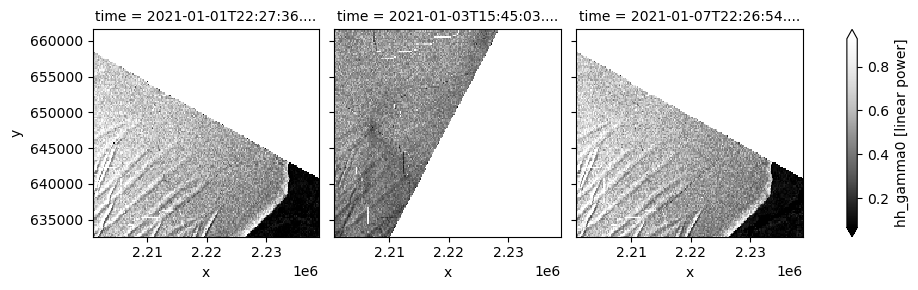

In [29]:
ds_by_scene.isel(time=range(0,3))["hh_gamma0"].plot.imshow(col="time", col_wrap=3, robust=True, cmap="Greys_r")